# Restaurant Sales Forecasting using Time Series Analysis

## Introduction

Time series forecasting plays a critical role in business decision-making, especially in domains like retail and food services where demand 
fluctuates over time.

In this project, we analyze restaurant sales data to:
- identify temporal patterns
- capture seasonality and trends
- build forecasting models using both statistical and machine learning approaches

We compare traditional time series models like SARIMA/SARIMAX with machine learning models to evaluate their effectiveness.

---

## Objective

To accurately forecast future sales using historical data while minimizing prediction error and understanding underlying patterns in the data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

plt.rcParams['figure.figsize'] = (20, 6)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('restaurant_sales.csv') #Loading Data
df.head()

,date,weekday,holiday,sales
0,1/1/2016,Friday,1,296.0
1,1/2/2016,Saturday,0,191.0
2,1/3/2016,Sunday,0,202.0
3,1/4/2016,Monday,0,105.0
4,1/5/2016,Tuesday,0,98.0


In [3]:
df.shape

(517, 4)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     517 non-null    object 
 1   weekday  517 non-null    object 
 2   holiday  517 non-null    int64  
 3   sales    478 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 16.3+ KB


In [5]:
df['date'] = pd.to_datetime(df['date']) # change dtype of date col from object to datetime dtype

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     517 non-null    datetime64[ns]
 1   weekday  517 non-null    object        
 2   holiday  517 non-null    int64         
 3   sales    478 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 16.3+ KB


In [7]:
df

,date,weekday,holiday,sales
0,2016-01-01,Friday,1,296.0
1,2016-01-02,Saturday,0,191.0
2,2016-01-03,Sunday,0,202.0
3,2016-01-04,Monday,0,105.0
4,2016-01-05,Tuesday,0,98.0
...,...,...,...,...
512,2017-05-27,Saturday,0,NaN
513,2017-05-28,Sunday,0,NaN
514,2017-05-29,Monday,1,NaN
515,2017-05-30,Tuesday,0,NaN


In [8]:
366+31+28+31+30+31 #leap year + 5 months (no missing values in date column)

517

In [9]:
df.set_index('date', inplace=True)

In [10]:
df.head()

,weekday,holiday,sales
date,,,
2016-01-01,Friday,1,296.0
2016-01-02,Saturday,0,191.0
2016-01-03,Sunday,0,202.0
2016-01-04,Monday,0,105.0
2016-01-05,Tuesday,0,98.0


In [11]:
df.sales.describe()

count    478.000000
mean     133.792887
std       59.736116
min       40.000000
25%       86.000000
50%      119.000000
75%      176.750000
max      316.000000
Name: sales, dtype: float64

In [12]:
df.isna().sum() # checking missing values

weekday     0
holiday     0
sales      39
dtype: int64

In [13]:
df.loc[df.sales.isna()] # Missing values are last 39 values

,weekday,holiday,sales
date,,,
2017-04-23,Sunday,0,NaN
2017-04-24,Monday,0,NaN
2017-04-25,Tuesday,0,NaN
2017-04-26,Wednesday,0,NaN
2017-04-27,Thursday,0,NaN
2017-04-28,Friday,0,NaN
2017-04-29,Saturday,0,NaN
2017-04-30,Sunday,0,NaN
2017-05-01,Monday,0,NaN


In [14]:
forecast_data = df.iloc[-39:] # adding last 39 values as a part of our forecast data
df = df.iloc[:-39]

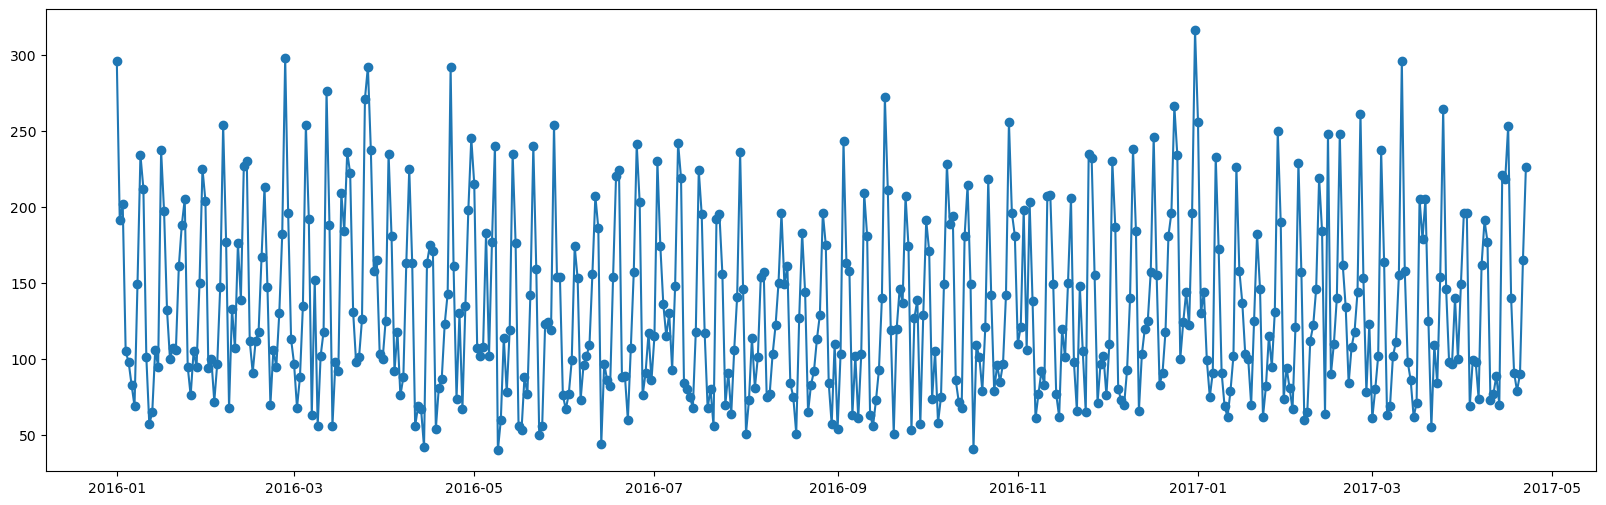

In [15]:
plt.plot(df.index, df['sales'], '-o')
plt.show()

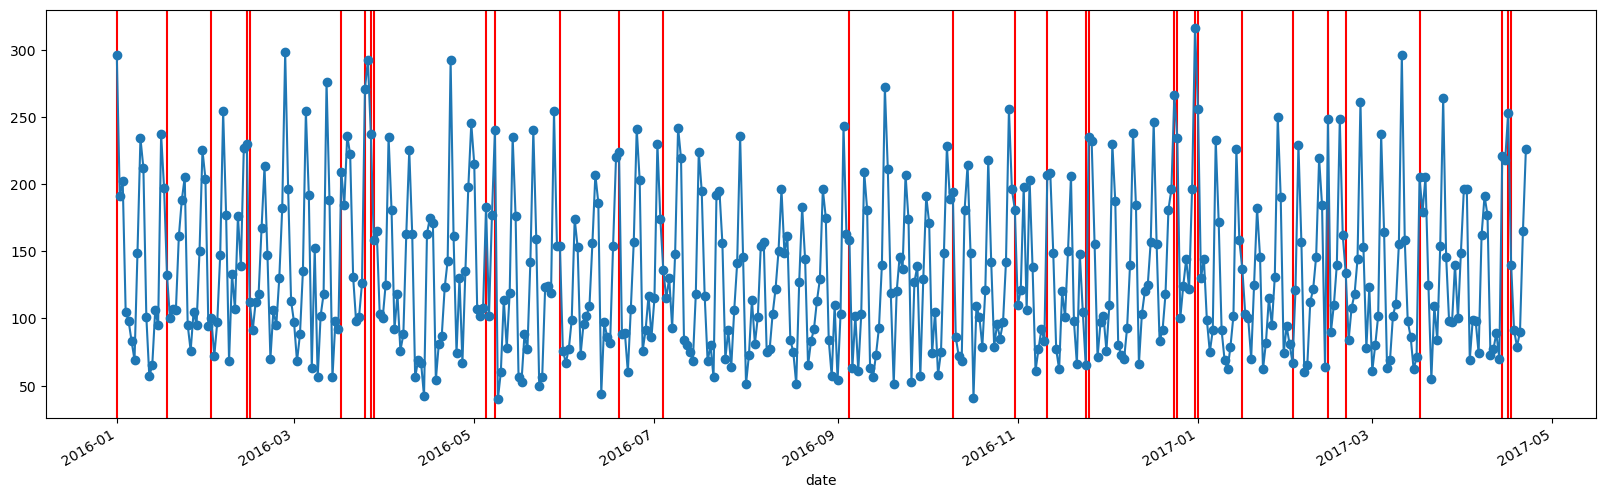

In [16]:
holidays = df.loc[df.holiday==1].index
for hday in holidays:
    plt.axvline(x=hday, color='red')
df.sales.plot(style='-o')
plt.show()

### Exploratory Insights

- The time series shows a straight trend in sales over time.
- Seasonal patterns are observed, likely corresponding to weekly cycles.
- Holiday periods show noticeable spikes/drops in sales.

These patterns suggest that both trend and seasonality must be modeled explicitly.

In [17]:
train = df.iloc[:-48] #Time Series based train-test split
test = df.iloc[-48:]

In [18]:
test.tail(6)

,weekday,holiday,sales
date,,,
2017-04-17,Monday,1,140.0
2017-04-18,Tuesday,0,91.0
2017-04-19,Wednesday,0,79.0
2017-04-20,Thursday,0,90.0
2017-04-21,Friday,0,165.0
2017-04-22,Saturday,0,226.0


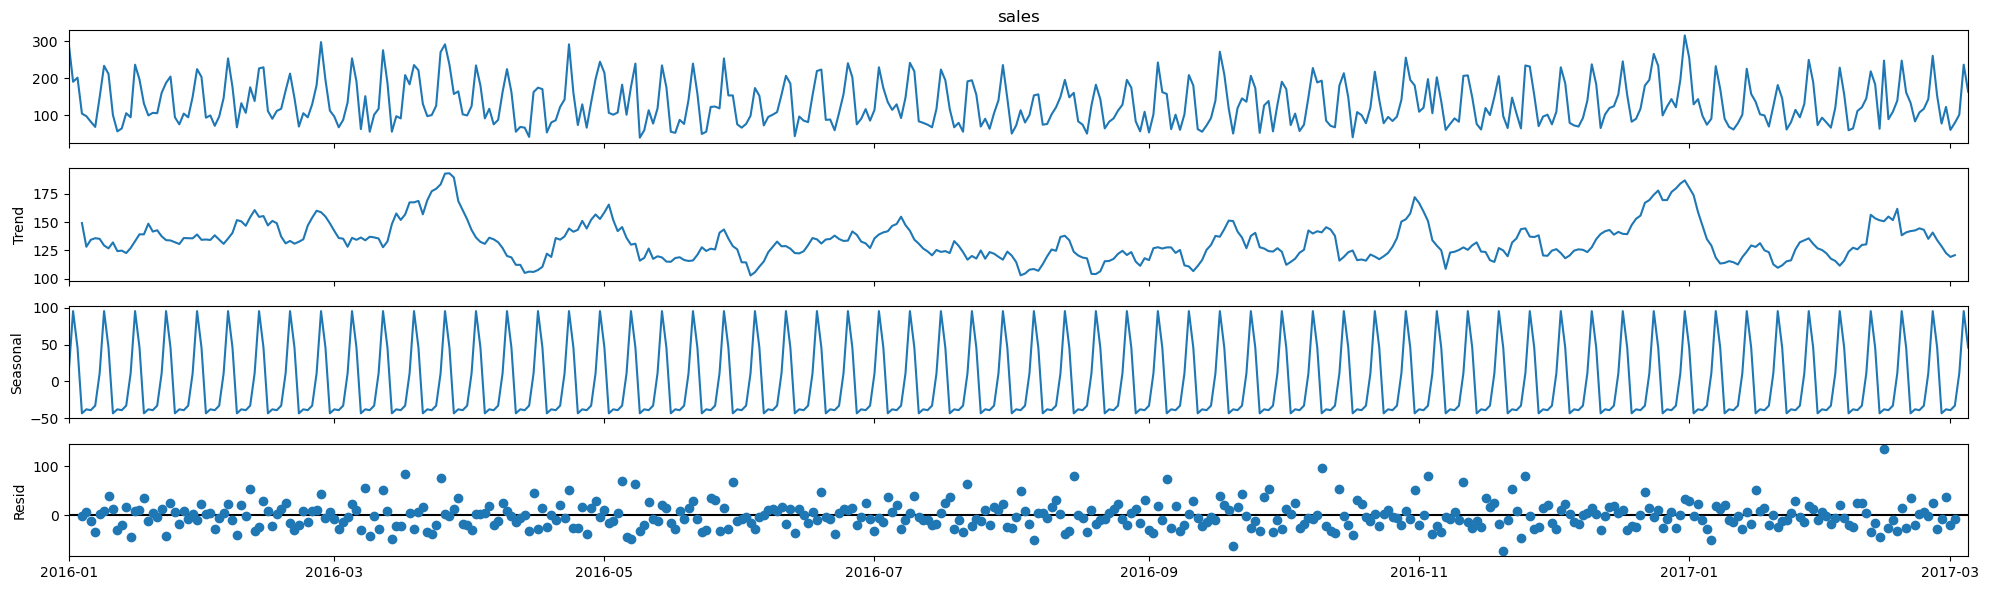

In [19]:
sd = sm.tsa.seasonal_decompose(train['sales'], model='additive') #Seasonal Decomposition of our time series
sd.plot();

### Time Series Decomposition Insights

- Trend component shows: **stable**
- Seasonality indicates: **weekly pattern**
- Residuals capture irregular fluctuations

The presence of strong seasonality justifies the use of **SARIMA/SARIMAX** models.

In [20]:
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape
)

# Creating a function to print values of all these metrics.
def performance(actual, predicted):
    print('MAE :', round(mae(actual, predicted), 3))
    print('RMSE :', round(mse(actual, predicted)**0.5, 3))
    print('MAPE:', round(mape(actual, predicted)*100, 3))

## Forecast

### Global Mean

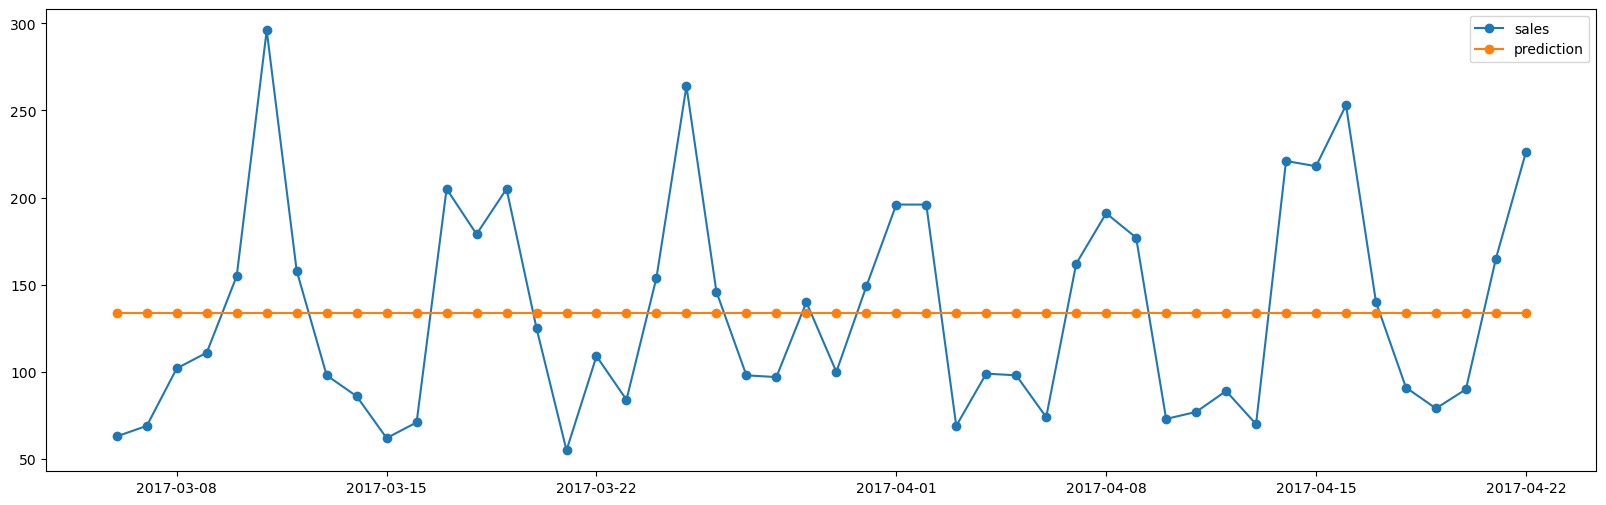

MAE : 51.918
RMSE : 60.55
MAPE: 45.683


In [21]:
test['pred'] = train.sales.mean()

plt.plot(test.index, test.sales, '-o', label='sales')
plt.plot(test.index, test.pred, '-o', label='prediction')
plt.legend()
plt.show()

performance(test.sales, test.pred)

### Naive

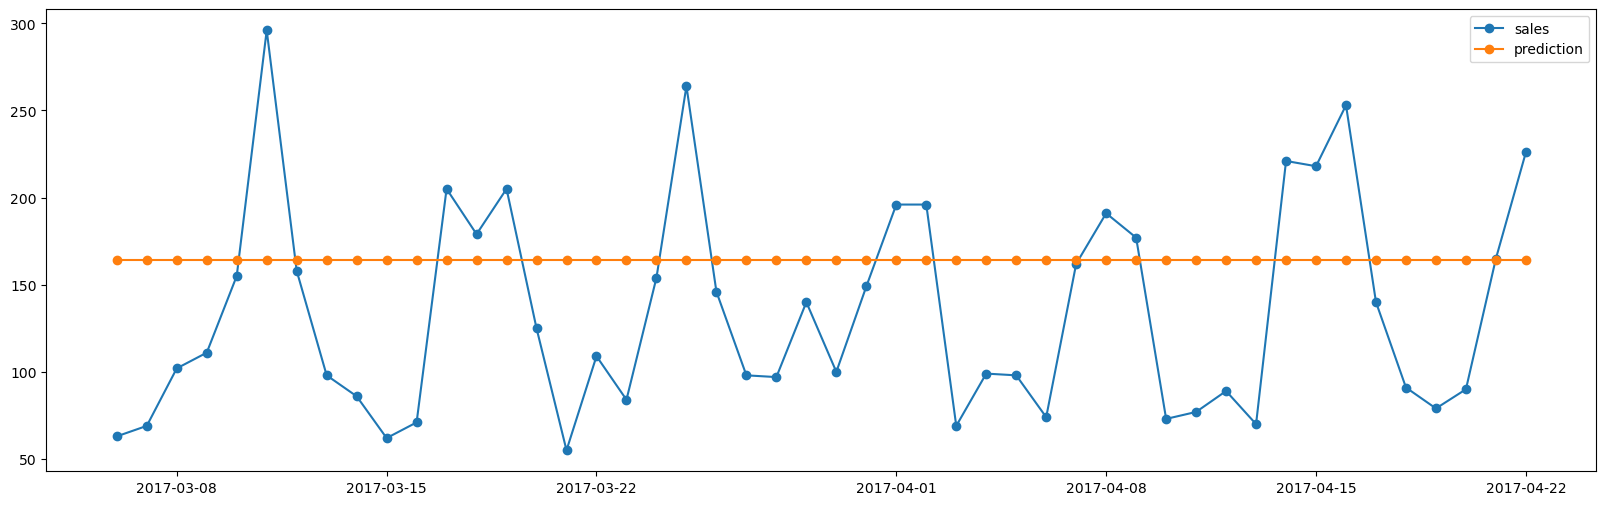

MAE : 58.938
RMSE : 67.546
MAPE: 60.977


In [22]:
test['pred'] = train.sales[-1]

plt.plot(test.index, test.sales, '-o', label='sales')
plt.plot(test.index, test.pred, '-o', label='prediction')
plt.legend()
plt.show()

performance(test.sales, test.pred)

### Seasonal Naive

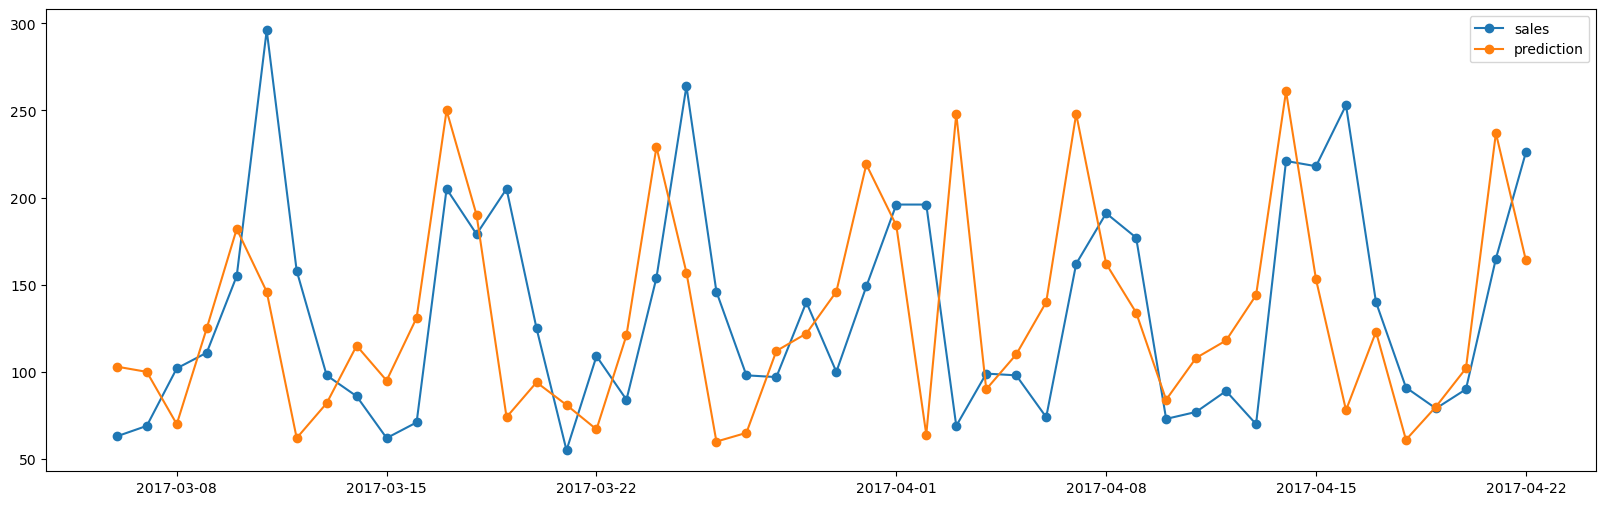

MAE : 51.833
RMSE : 67.346
MAPE: 41.589


In [23]:
test['pred'] = train.sales.values[-48:]

plt.plot(test.index, test.sales, '-o', label='sales')
plt.plot(test.index, test.pred, '-o', label='prediction')
plt.legend()
plt.show()

performance(test.sales, test.pred)

### Simple Exponential Smoothing (SES)

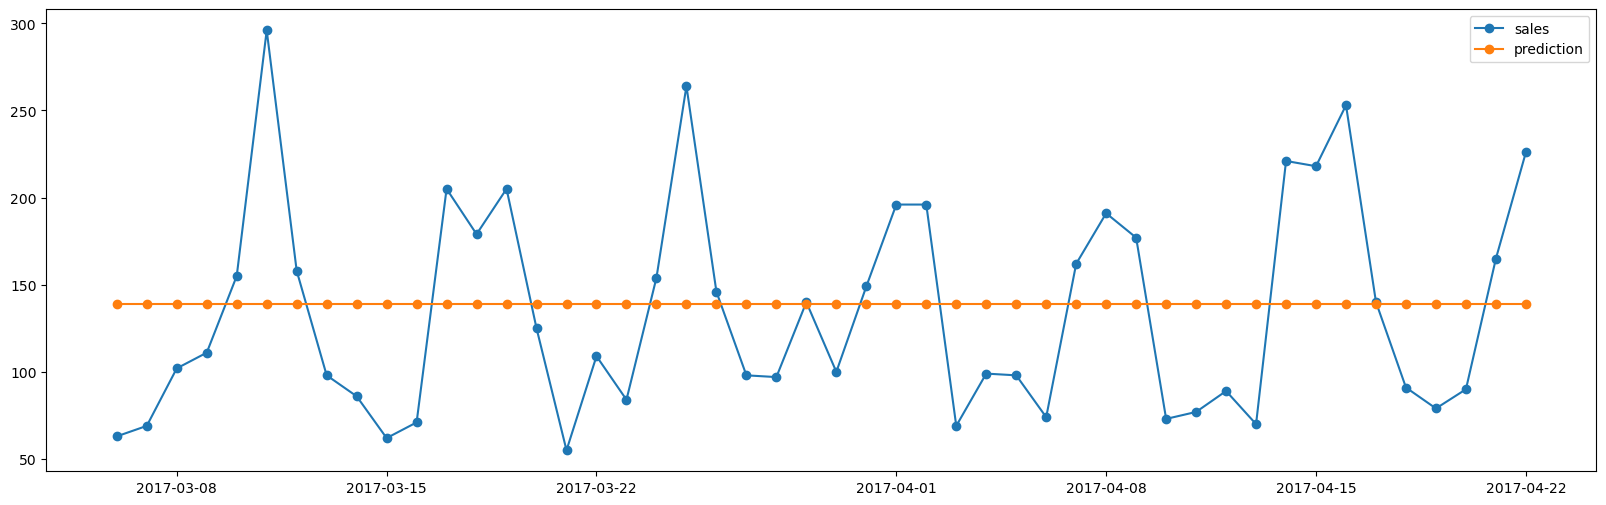

MAE : 52.339
RMSE : 60.736
MAPE: 47.724


In [24]:
ses = sm.tsa.SimpleExpSmoothing(train.sales).fit()
test['pred'] = ses.forecast(48)

plt.plot(test.index, test.sales, '-o', label='sales')
plt.plot(test.index, test.pred, '-o', label='prediction')
plt.legend()
plt.show()

performance(test.sales, test.pred)

### Double Exponential Smoothing (DES)

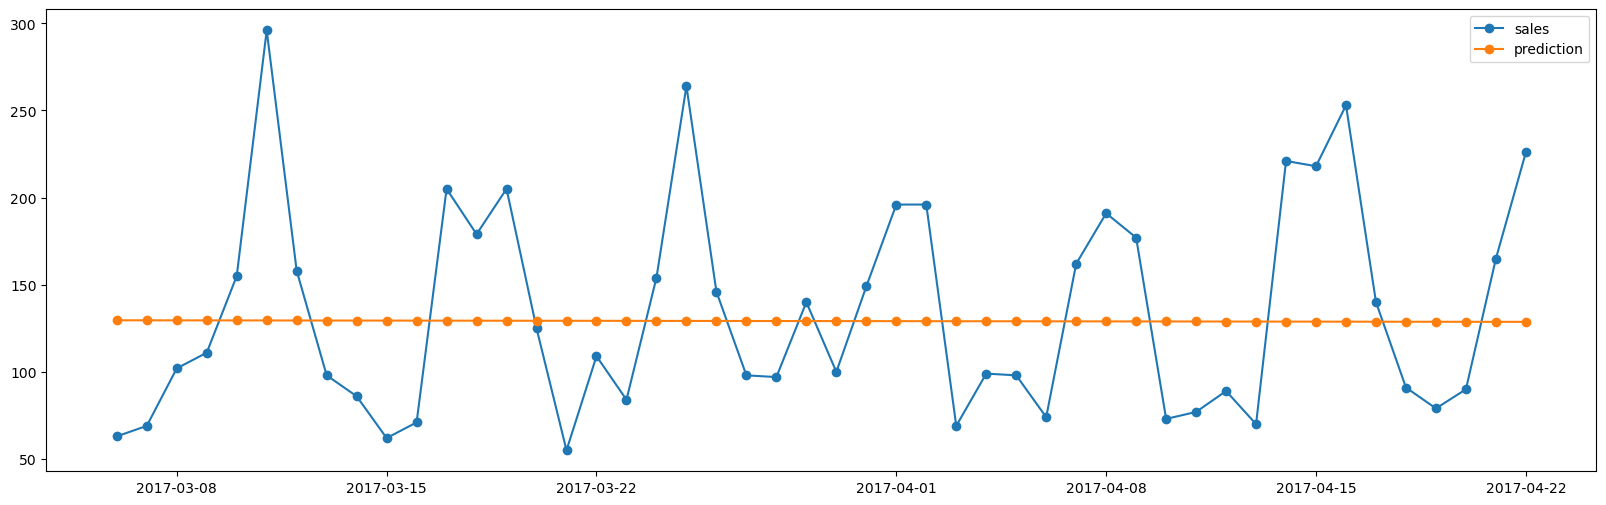

MAE : 51.569
RMSE : 60.78
MAPE: 43.848


In [25]:
des = sm.tsa.ExponentialSmoothing(train.sales, trend='add').fit()
test['pred'] = des.forecast(48)

plt.plot(test.index, test.sales, '-o', label='sales')
plt.plot(test.index, test.pred, '-o', label='prediction')
plt.legend()
plt.show()

performance(test.sales, test.pred)

### Triple Exponential Smoothing (TES)

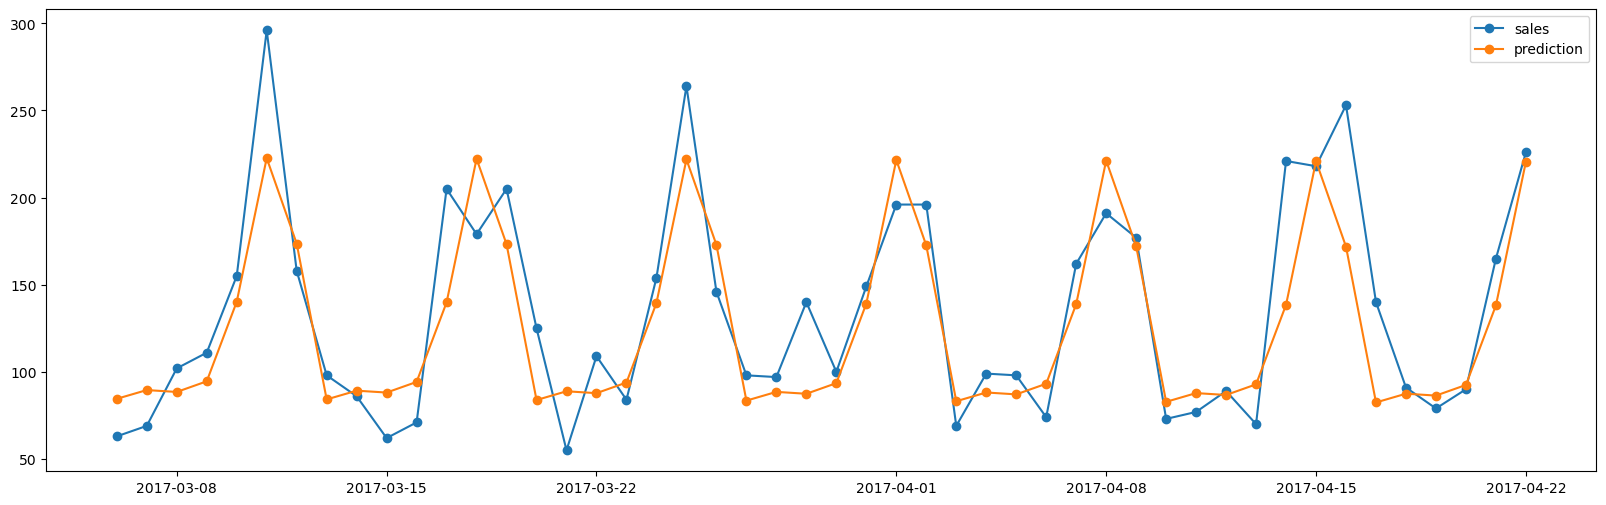

MAE : 23.785
RMSE : 31.217
MAPE: 18.324


In [26]:
tes = sm.tsa.ExponentialSmoothing(train.sales, trend='add', seasonal='add').fit()
test['pred'] = tes.forecast(48)

plt.plot(test.index, test.sales, '-o', label='sales')
plt.plot(test.index, test.pred, '-o', label='prediction')
plt.legend()
plt.show()

performance(test.sales, test.pred)

### ARMA/SARIMA/SARIMAX

In [27]:
def adf_test(dataset): #Ad-fuller Test (for checking Stationarity)
   pvalue = sm.tsa.stattools.adfuller(dataset)[1]
   if pvalue <= 0.05:
      print('Sequence is stationary')
   else:
      print('Sequence is not stationary')

In [28]:
adf_test(train.sales)

Sequence is stationary


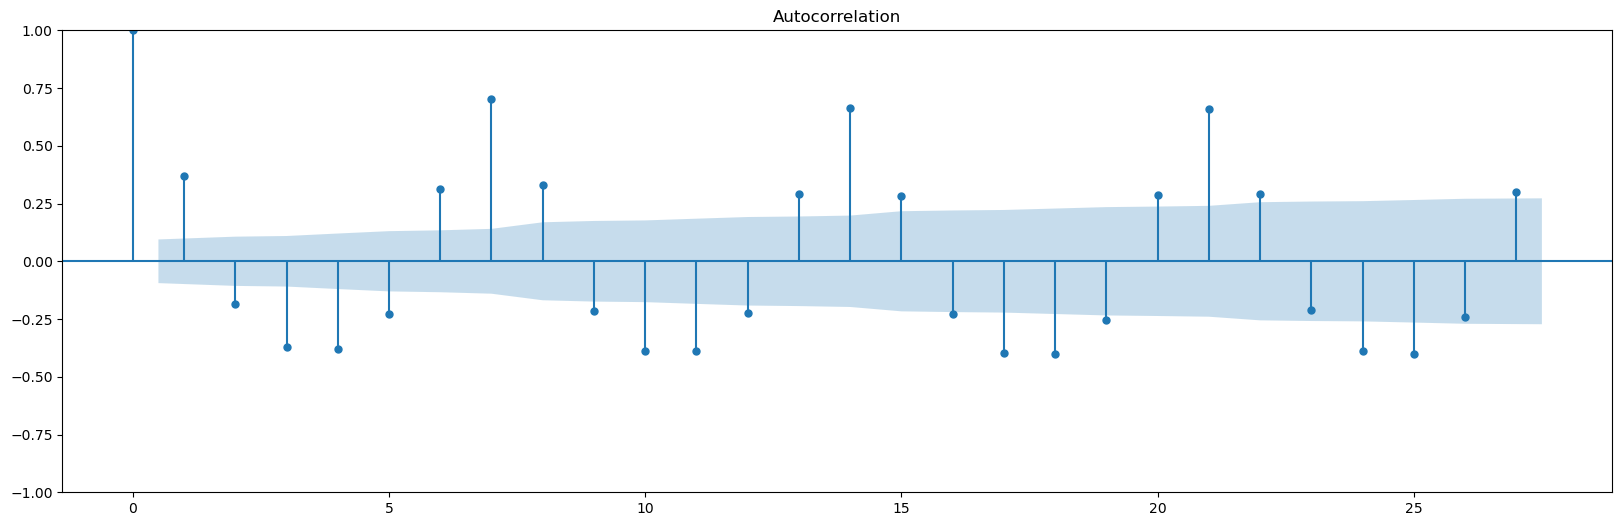

In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(train.sales);

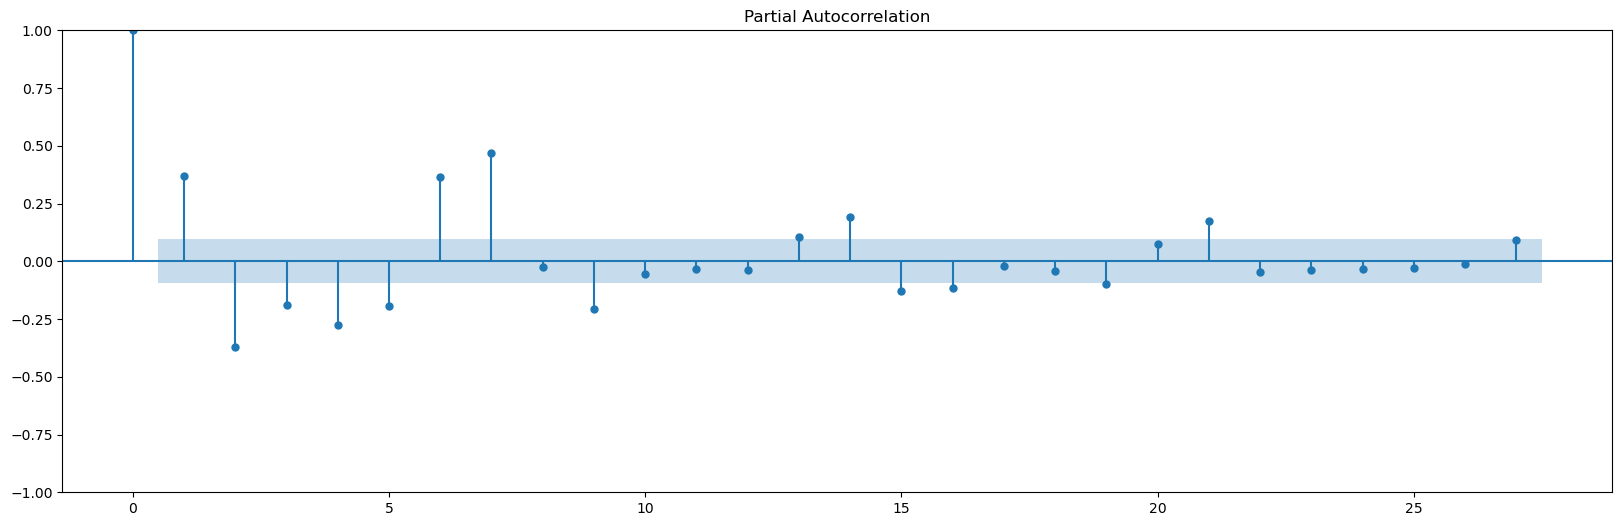

In [30]:
plot_pacf(train.sales);

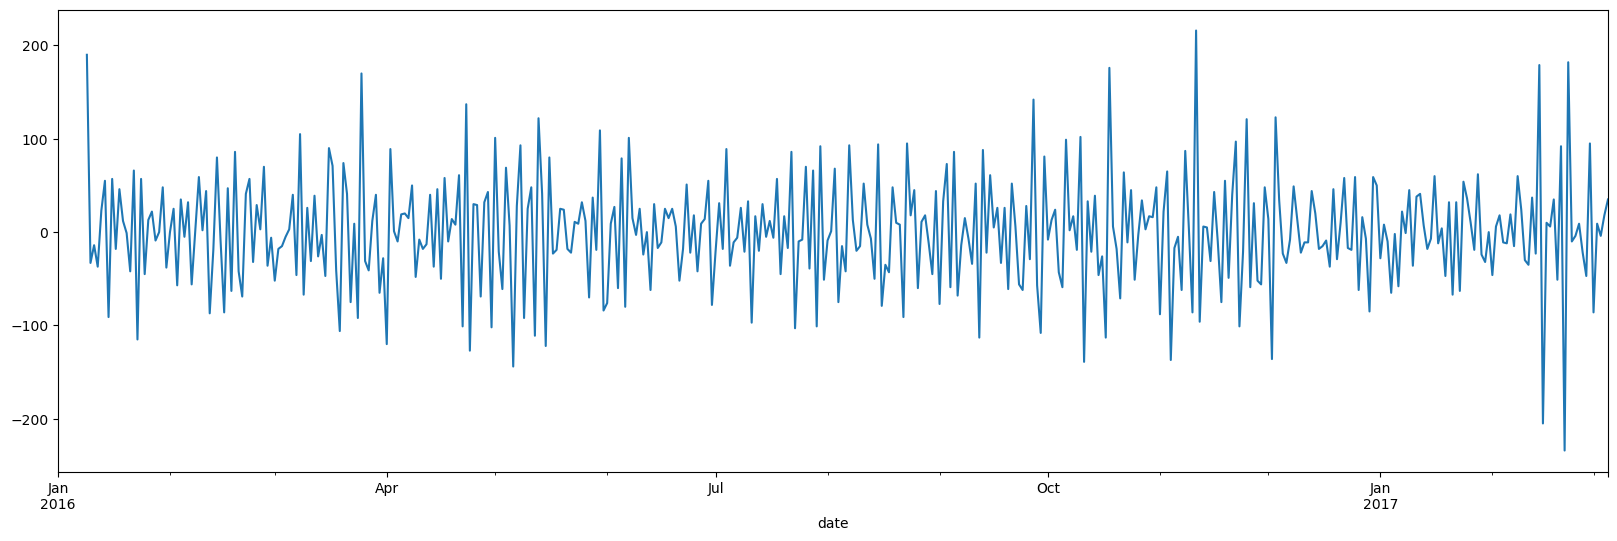

In [31]:
resid = train.sales.diff(1).diff(7) # Sales - trend - seasonality = errors
resid.plot();

<Axes: xlabel='sales', ylabel='Count'>

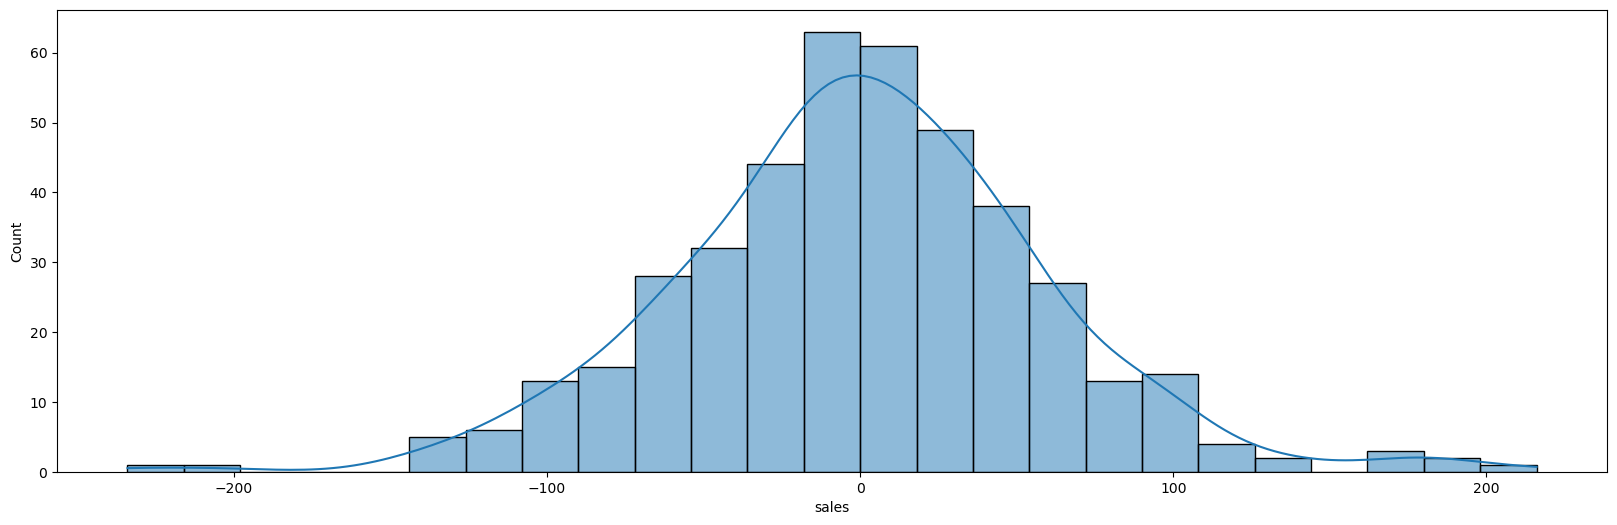

In [32]:
sns.histplot(resid, kde=True) #Looks normally distributed

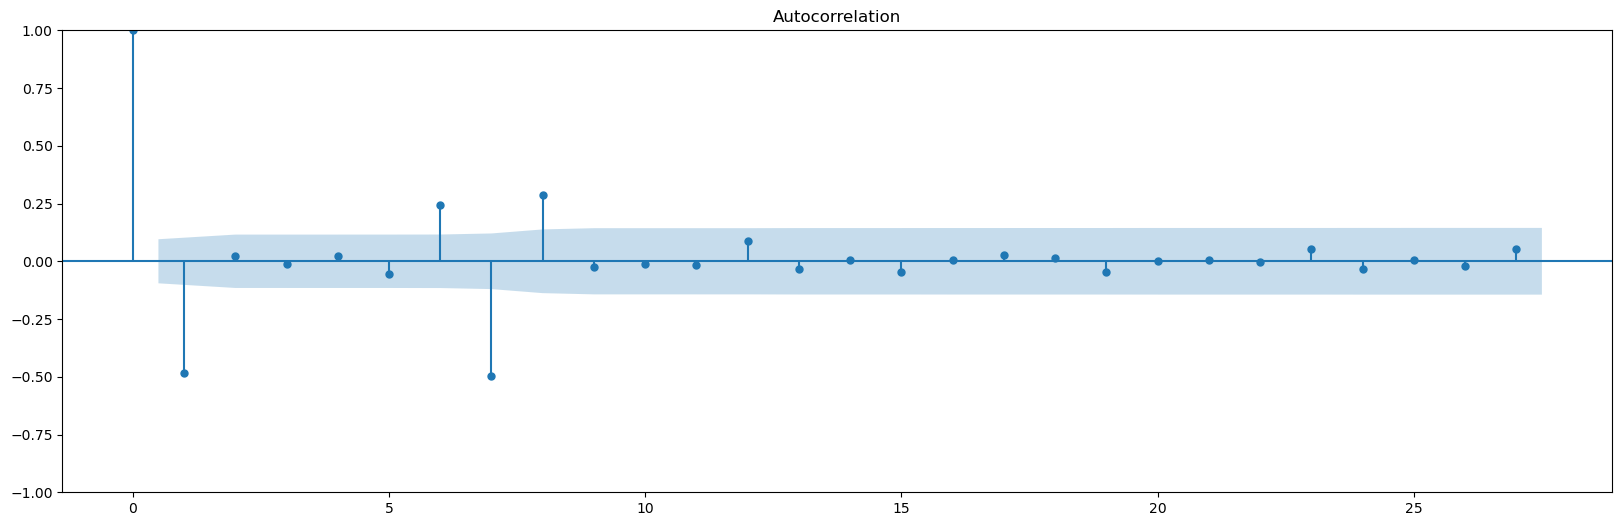

In [33]:
plot_acf(resid.dropna()); # No seasonality pattern observed in residual acf plot

### Residual Diagnostics

Residual analysis helps validate whether the model has captured all patterns in the data.

- Residuals should be normally distributed
- Residuals should not show autocorrelation

**Observations**:
- Residuals resemble white noise (Staionarity) → model is good

This step is critical to validate model assumptions.

### SARIMA Model Selection

The SARIMA model parameters (p,d,q)(P,D,Q,s) are selected based on:

- ACF (Auto-Correlation Function) → helps identify MA terms
- PACF (Partial Auto-Correlation Function) → helps identify AR terms
- Seasonal patterns observed in decomposition

Seasonal period is chosen based on repeating patterns in the data.

Proper parameter selection is crucial for capturing temporal dependencies effectively.

#### ARMA

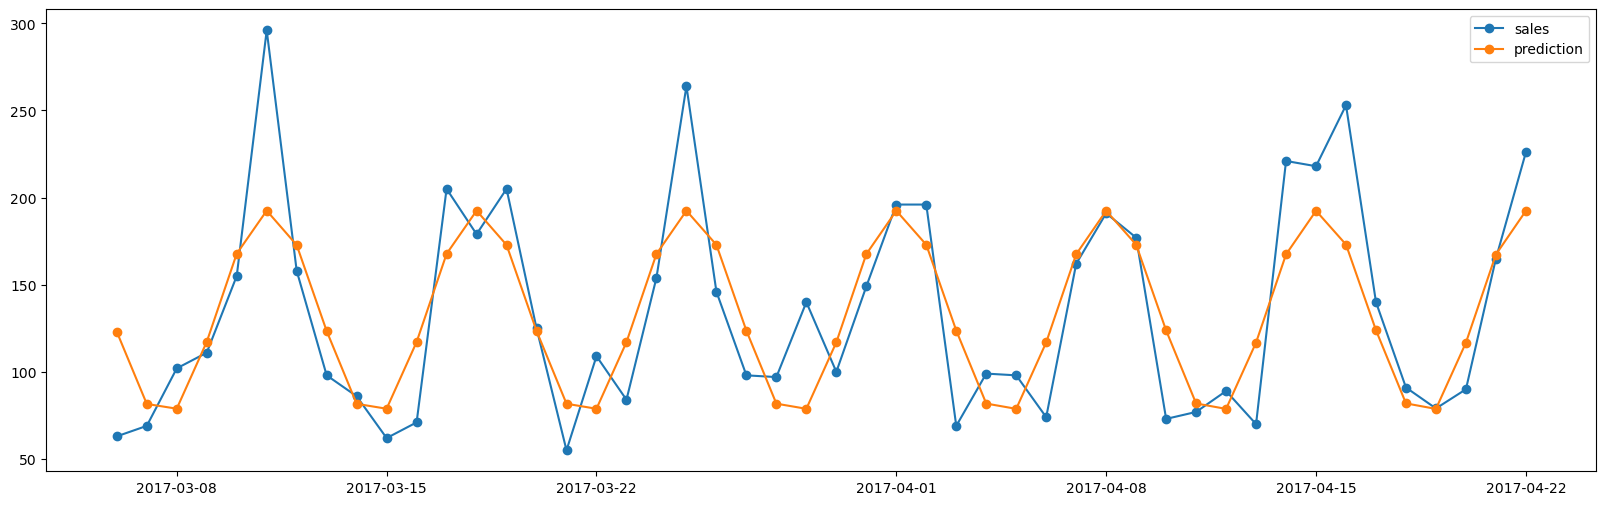

MAE : 26.694
RMSE : 34.828
MAPE: 23.52


In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX #parameters selected based on best MAPE score
model = SARIMAX(train.sales, order=(3, 1, 3))
model = model.fit(disp=False)
test['pred'] = model.forecast(48)

plt.plot(test.index, test.sales, '-o', label='sales')
plt.plot(test.index, test.pred, '-o', label='prediction')
plt.legend()
plt.show()

performance(test.sales, test.pred)

#### SARIMA

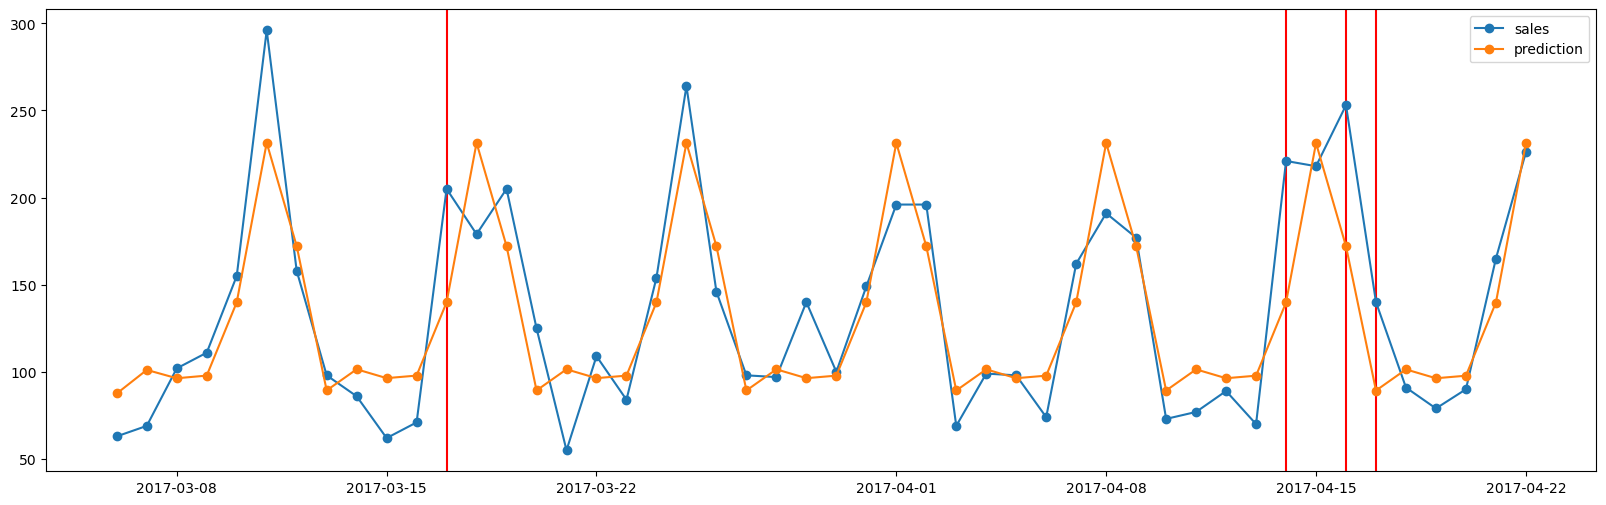

MAE : 24.946
RMSE : 31.689
MAPE: 20.423


In [35]:
from statsmodels.tsa.statespace.sarimax import SARIMAX #parameters selected based on best MAPE score
model = SARIMAX(train.sales, order=(1, 0, 0), seasonal_order=(1, 0, 1, 7))
model = model.fit(disp=False)
test['pred'] = model.forecast(48)

holidays = test.loc[test.holiday==1].index
for hday in holidays:
    plt.axvline(x=hday, color='red')
plt.plot(test.index, test.sales, '-o', label='sales')
plt.plot(test.index, test.pred, '-o', label='prediction')
plt.legend()
plt.show()

performance(test.sales, test.pred)

#### SARIMAX

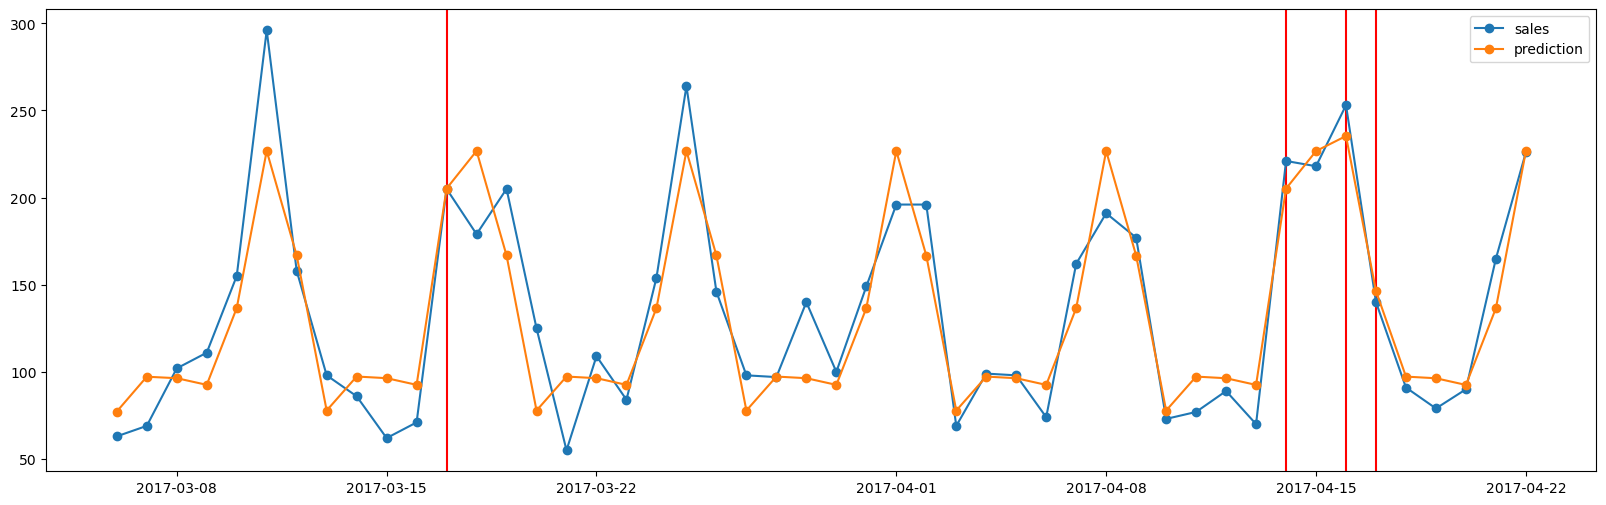

MAE : 19.324
RMSE : 24.359
MAPE: 16.512


In [36]:
model = SARIMAX(train.sales, order=(1, 0, 0), seasonal_order=(1, 0, 1, 7), exog=train.holiday) #parameters selected based on best MAPE score
model = model.fit(disp=False)
test['pred'] = model.forecast(48, exog=test.holiday)

for hday in holidays:
    plt.axvline(x=hday, color='red')
plt.plot(test.index, test.sales, '-o', label='sales')
plt.plot(test.index, test.pred, '-o', label='prediction')
plt.legend()
plt.show()

performance(test.sales, test.pred)

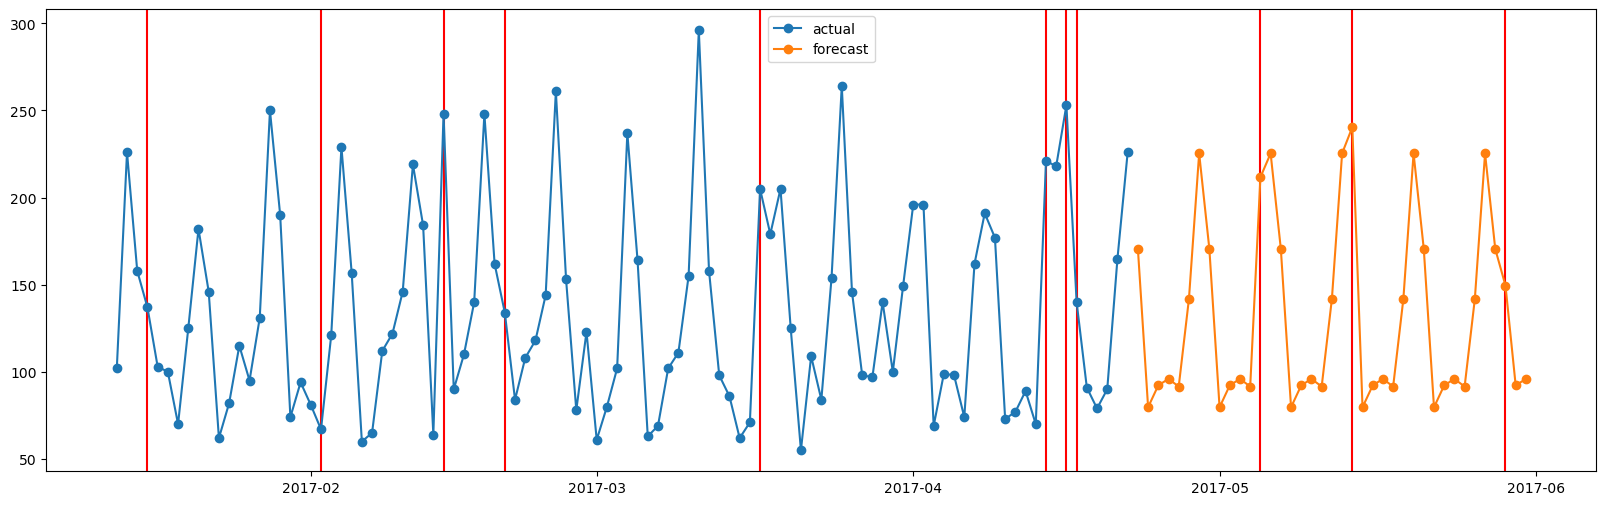

In [37]:
model = SARIMAX(df.sales, order=(1, 0, 0), seasonal_order=(1, 0, 1, 7), exog=df.holiday) #Forecasting on forecast data
model = model.fit(disp=False)
forecast_data['pred'] = model.forecast(39, exog=forecast_data.holiday)

for hday in forecast_data.loc[forecast_data.holiday==1].index:
    plt.axvline(x=hday, color='red')
for hday in df[-100:].loc[df.holiday==1].index:
    plt.axvline(x=hday, color='red')
plt.plot(df.index[-100:], df.sales[-100:], '-o', label='actual')
plt.plot(forecast_data.index, forecast_data.pred, '-o', label='forecast')
plt.legend();

## ML Modelling

### Data Prep and Feature Engineering

In [38]:
df1 = df.copy()

In [39]:
df.reset_index(inplace=True)

In [40]:
df["weekend"] = np.where(((df["weekday"] == "Saturday") | (df["weekday"] == "Sunday")), 1, 0)

In [41]:
for i in range(1,32):
  df[f"Lag_{i}"] = df.sales.shift(i)

In [42]:
df.dropna(inplace=True)

In [43]:
lis = [f"Lag_{i}" for i in range(1, 32)]
df['last_month_avg_level'] = df.loc[:,lis].sum(axis=1)/31
df.head()

,date,weekday,holiday,sales,weekend,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,...,Lag_23,Lag_24,Lag_25,Lag_26,Lag_27,Lag_28,Lag_29,Lag_30,Lag_31,last_month_avg_level
31,2016-02-01,Monday,0,94.0,0,204.0,225.0,150.0,95.0,105.0,...,234.0,149.0,69.0,83.0,98.0,105.0,202.0,191.0,296.0,143.419355
32,2016-02-02,Tuesday,1,100.0,0,94.0,204.0,225.0,150.0,95.0,...,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0,191.0,136.903226
33,2016-02-03,Wednesday,0,72.0,0,100.0,94.0,204.0,225.0,150.0,...,101.0,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0,133.967742
34,2016-02-04,Thursday,0,97.0,0,72.0,100.0,94.0,204.0,225.0,...,57.0,101.0,212.0,234.0,149.0,69.0,83.0,98.0,105.0,129.774194
35,2016-02-05,Friday,0,147.0,0,97.0,72.0,100.0,94.0,204.0,...,65.0,57.0,101.0,212.0,234.0,149.0,69.0,83.0,98.0,129.516129


In [44]:
lis = [f'Lag_{i}' for i in range(1,8)]
df['last_week_avg_level'] = df.loc[:,lis].sum(axis=1)/7
df.head(3)

,date,weekday,holiday,sales,weekend,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,...,Lag_24,Lag_25,Lag_26,Lag_27,Lag_28,Lag_29,Lag_30,Lag_31,last_month_avg_level,last_week_avg_level
31,2016-02-01,Monday,0,94.0,0,204.0,225.0,150.0,95.0,105.0,...,149.0,69.0,83.0,98.0,105.0,202.0,191.0,296.0,143.419355,135.714286
32,2016-02-02,Tuesday,1,100.0,0,94.0,204.0,225.0,150.0,95.0,...,234.0,149.0,69.0,83.0,98.0,105.0,202.0,191.0,136.903226,135.571429
33,2016-02-03,Wednesday,0,72.0,0,100.0,94.0,204.0,225.0,150.0,...,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0,133.967742,139.000000


In [45]:
lis = [f'Lag_{i}' for i in range(1,15)]
df['last_2week_avg_level'] = df.loc[:,lis].sum(axis=1)/14
df.head(3)

,date,weekday,holiday,sales,weekend,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,...,Lag_25,Lag_26,Lag_27,Lag_28,Lag_29,Lag_30,Lag_31,last_month_avg_level,last_week_avg_level,last_2week_avg_level
31,2016-02-01,Monday,0,94.0,0,204.0,225.0,150.0,95.0,105.0,...,69.0,83.0,98.0,105.0,202.0,191.0,296.0,143.419355,135.714286,139.214286
32,2016-02-02,Tuesday,1,100.0,0,94.0,204.0,225.0,150.0,95.0,...,149.0,69.0,83.0,98.0,105.0,202.0,191.0,136.903226,135.571429,136.500000
33,2016-02-03,Wednesday,0,72.0,0,100.0,94.0,204.0,225.0,150.0,...,234.0,149.0,69.0,83.0,98.0,105.0,202.0,133.967742,139.000000,136.500000


In [46]:
df['dayofweek'] = df.date.dt.dayofweek
df['sale_wrt_dow'] = df.groupby('dayofweek')['sales'].transform('mean')

In [47]:
df[['dayofweek', 'sale_wrt_dow']].drop_duplicates()

,dayofweek,sale_wrt_dow
31,0,89.593750
32,1,94.531250
33,2,94.687500
34,3,99.015625
35,4,147.171875
36,5,229.125000
37,6,178.460317


In [48]:
df.head(3)

,date,weekday,holiday,sales,weekend,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,...,Lag_27,Lag_28,Lag_29,Lag_30,Lag_31,last_month_avg_level,last_week_avg_level,last_2week_avg_level,dayofweek,sale_wrt_dow
31,2016-02-01,Monday,0,94.0,0,204.0,225.0,150.0,95.0,105.0,...,98.0,105.0,202.0,191.0,296.0,143.419355,135.714286,139.214286,0,89.59375
32,2016-02-02,Tuesday,1,100.0,0,94.0,204.0,225.0,150.0,95.0,...,83.0,98.0,105.0,202.0,191.0,136.903226,135.571429,136.500000,1,94.53125
33,2016-02-03,Wednesday,0,72.0,0,100.0,94.0,204.0,225.0,150.0,...,69.0,83.0,98.0,105.0,202.0,133.967742,139.000000,136.500000,2,94.68750


In [49]:
df.shape

(447, 41)

In [50]:
df.columns

Index(['date', 'weekday', 'holiday', 'sales', 'weekend', 'Lag_1', 'Lag_2',
       'Lag_3', 'Lag_4', 'Lag_5', 'Lag_6', 'Lag_7', 'Lag_8', 'Lag_9', 'Lag_10',
       'Lag_11', 'Lag_12', 'Lag_13', 'Lag_14', 'Lag_15', 'Lag_16', 'Lag_17',
       'Lag_18', 'Lag_19', 'Lag_20', 'Lag_21', 'Lag_22', 'Lag_23', 'Lag_24',
       'Lag_25', 'Lag_26', 'Lag_27', 'Lag_28', 'Lag_29', 'Lag_30', 'Lag_31',
       'last_month_avg_level', 'last_week_avg_level', 'last_2week_avg_level',
       'dayofweek', 'sale_wrt_dow'],
      dtype='object')

In [51]:
df = df[['sales', 'Lag_1', 'last_month_avg_level', 'last_week_avg_level',
          'last_2week_avg_level', 'sale_wrt_dow', 'weekend', 'holiday']]
df.head()

,sales,Lag_1,last_month_avg_level,last_week_avg_level,last_2week_avg_level,sale_wrt_dow,weekend,holiday
31,94.0,204.0,143.419355,135.714286,139.214286,89.593750,0,0
32,100.0,94.0,136.903226,135.571429,136.500000,94.531250,0,1
33,72.0,100.0,133.967742,139.000000,136.500000,94.687500,0,0
34,97.0,72.0,129.774194,134.285714,134.000000,99.015625,0,0
35,147.0,97.0,129.516129,134.571429,133.357143,147.171875,0,0


### Feature Engineering for ML Models

To adapt machine learning models for time series forecasting, we created:

- Lag features (1–31 days)
- Rolling averages:
  - weekly
  - biweekly
  - monthly
- Day-wise average sales
- Feature Selection

These features help transform temporal dependencies into structured inputs for ML models.

In [52]:
train = df.iloc[:-42] #train-test split for time series
test = df.iloc[-42:]

X_train = train.drop(["sales"],axis =1)
y_train = train['sales']
X_test = test.drop(["sales"],axis =1)
y_test = test['sales']

In [53]:
train.shape

(405, 8)

In [54]:
test.shape

(42, 8)

In [55]:
test.head()

,sales,Lag_1,last_month_avg_level,last_week_avg_level,last_2week_avg_level,sale_wrt_dow,weekend,holiday
436,158.0,296.0,141.161290,137.142857,128.142857,178.460317,1,0
437,98.0,158.0,142.322581,136.285714,128.500000,89.593750,0,0
438,86.0,98.0,140.774194,141.285714,129.928571,94.531250,0,0
439,62.0,86.0,136.483871,143.714286,127.285714,94.687500,0,0
440,71.0,62.0,132.548387,138.000000,127.357143,99.015625,0,0


In [56]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_percentage_error as mape, make_scorer

#### Linear Regression (baseline model)

In [57]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
mape(y_test, lr.predict(X_test))

0.1549900596252351

In [59]:
tscv = TimeSeriesSplit(n_splits=5)
cv = cross_validate(lr, X_train, y_train, cv=tscv, scoring='neg_mean_absolute_percentage_error', return_train_score=True)

In [60]:
cv['test_score'].mean()

-0.2177790151303643

#### Random Forest Regressor

In [61]:
params = {
    'n_estimators' : [100, 200, 250, 300],
    'max_depth' : [3, 5, 10]
} # Parameter selection done based on best MAPE score

In [62]:
rf_reg = RandomForestRegressor(random_state=42)
tscv = TimeSeriesSplit(n_splits=5)
gcv = GridSearchCV(rf_reg, params, cv=tscv, scoring='neg_mean_absolute_percentage_error', return_train_score=True)
gcv.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'neg_mean_absolute_percentage_error'
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,250


In [63]:
gcv.best_params_

{'max_depth': 3, 'n_estimators': 250}

In [64]:
gcv.best_score_

-0.24646256438770262

#### XGBoost Regressor

In [65]:
params = {
    'n_estimators' : [10, 20, 30],
    'max_depth' : [1, 2, 3],
    'subsample' : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.7, 0.8, 0.9, 1.0]
} # Parameter selection done based on best MAPE score

In [66]:
xgb_reg = xgb.XGBRegressor(random_state=42)
tscv = TimeSeriesSplit(n_splits=5)
gcv = GridSearchCV(xgb_reg, params, cv=tscv, scoring='neg_mean_absolute_percentage_error', return_train_score=True)
gcv.fit(X_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.7, 0.8, ...], 'max_depth': [1, 2, ...], 'n_estimators': [10, 20, ...], 'subsample': [0.7, 0.8, ...]}"
,scoring,'neg_mean_absolute_percentage_error'
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,objective,'reg:squarederror'


In [67]:
gcv.best_params_

{'colsample_bytree': 1.0, 'max_depth': 1, 'n_estimators': 30, 'subsample': 0.9}

In [68]:
gcv.best_score_

-0.2363706038102233

## Model Comparison Insights

- Linear Regression performed competitively due to strong feature engineering.
- Lag and rolling features effectively captured temporal patterns.
- Tree-based models (Random Forest, XGBoost) did not outperform, possibly due to:
  - low data
  - high feature redundancy
  - overfitting to noise
  - lack of additional non-linear signals

- SARIMAX performance depends heavily on parameter tuning and seasonal configuration.

***Key Insight***:
Well-engineered features can significantly reduce the need for complex models.

In [69]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": np.abs(lr.coef_)
})
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

In [71]:
feature_importance

,Feature,Coefficient
6,holiday,62.909758
5,weekend,2.002279
4,sale_wrt_dow,1.021818
2,last_week_avg_level,0.311601
1,last_month_avg_level,0.121275
3,last_2week_avg_level,0.067555
0,Lag_1,0.000212


<Figure size 700x500 with 0 Axes>

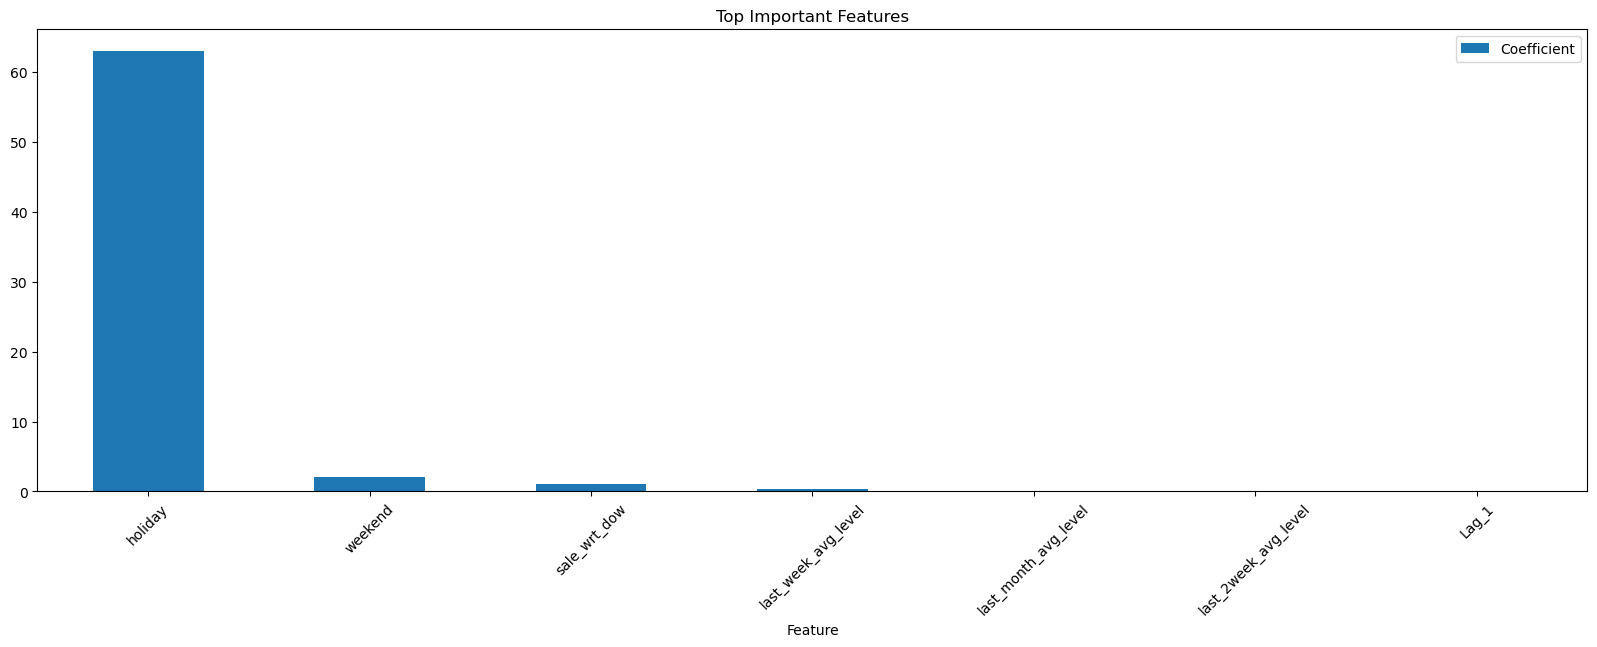

In [72]:
plt.figure(figsize=(7,5))
feature_importance.set_index('Feature').plot(kind='bar')
plt.title("Top Important Features")
plt.xticks(rotation=45)
plt.show()

### Feature Importance Analysis

Feature importance helps identify which features contribute most to predictions. Since Linear Regression performed best, we analyze feature importance using model coefficients.

**Key Insights**:
- `holiday` dominates importance (as can be seen in SARIMAX models as well)
- `sale_wrt_dow` is another highly important feature infulencing prediction
- Importance decreases for values of higher lags as was concluded using the PACF plot

This analysis helps reduce feature redundancy and improve model efficiency.

## Conclusion

- Time series forecasting requires both statistical understanding and feature engineering.
- SARIMA/SARIMAX models are powerful for capturing structured temporal patterns.
- Machine learning models can perform well when provided with carefully engineered lag-based features.
- Simpler models like Linear Regression can outperform complex models when features are informative.

---

## Future Improvements

- Perform residual diagnostics to validate model assumptions
- Explore advanced models like Prophet or LSTM (NN based methods)

## Business Insights

- Sales show clear seasonal patterns, indicating predictable demand cycles
- Recent sales (lag features) has good influence on future demand but higher lags show none
- Model can help:
  - optimize inventory
  - plan staffing
  - reduce wastage

Accurate forecasting directly impacts profitability and operational efficiency.